# EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

**Group Members:** Jingqi Lu, Tessa Vu, Ming Cao
**Submission Date:** 2026-03-21

This notebook contains the complete assignment instructions and implementation for EuroSAT LULC classification with traditional ML and deep learning models.

## Assignment Instructions

### 1. Data Loading, Processing, and Exploration
1.1 Data Preparation:
- Load EuroSAT data and perform basic EDA.
- Assess class distribution and plot one image from each class in a 2x5 grid.
- Flatten images to a 2D matrix (n x p), store data and labels in NumPy arrays.
- Split data into train (60%) and test (40%) with stratification.
- Create grayscale version for traditional ML and early deep learning models.

1.2 Data Augmentation:
- Apply augmentation before train/test split and preprocessing.
- Append augmented samples to original dataset and report new dataset size.
- Plot three random images and a label histogram of the full augmented dataset.

### 2. Traditional Machine Learning (Forest, Residential, Industrial only)
2.1 Binary SVM:
- Train linear SVM for [F vs R], [F vs I], [R vs I].
- Report accuracy, ROC, AUC.
- Show one misclassified image per binary classifier with prediction and ground truth.

2.2 Multiclass Majority-Vote SVM:
- Combine the three binary SVMs using majority vote.
- Report multiclass accuracy, ROC, AUC.
- Show one misclassified image from each class.

2.3 Multiclass Random Forest:
- Train on the same three-class grayscale subset.
- Report accuracy and confusion matrix.
- Show one misclassified image from each class.

### 3. Deep Learning
3.1 Grayscale Images (all 10 classes):
- 3.1.1 Single-layer fully connected network.
- 3.1.2 Two-layer fully connected network.
- 3.1.3 Four-layer fully connected network with dropout.
- Visualize architecture and report test accuracy for each model.
- Compare models, parameters, and epoch effects.
- Build ensemble from models 1-3 and evaluate.

3.2 RGB Images:
- 3.2.1 CNN model with Conv2D, MaxPooling2D, Dropout, Flatten, Dense.
- 3.2.2 Advanced model targeting best accuracy (for example transfer learning).
- Compare results and analyze top confusing classes with misclassified examples.

3.3 Multispectral Images:
- Apply best approach to EuroSAT multispectral images using more than RGB channels.
- Report test accuracy and compare with RGB results.

### 4. Reflection Questions
- Summarize parameter tuning lessons, epoch effects, dropout impact, ensemble behavior, challenges, and future improvements.

### 5. Submission Notes
- Submit as `assignments/eurosat.ipynb`.
- Put extra files in `assignments/eurosat_files/`.
- Run formatting/lint checks before submission.

In [1]:
import warnings
from pathlib import Path
import random

import imageio.v3 as iio
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [ ]:
# Paths and class names
CLASS_NAMES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake",
]

DISPLAY_NAMES = [
    "Annual/Crop",
    "Forest",
    "Herbaceous/Vegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "Permanent/Crop",
    "Residential",
    "River",
    "Sea/Lake",
]

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}


def find_dataset_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for c in candidates:
        if (c / "EuroSAT_RGB").exists() and (c / "EuroSAT_MS").exists():
            return c
    raise FileNotFoundError("Could not find EuroSAT_RGB and EuroSAT_MS folders.")


DATA_ROOT = find_dataset_root()
RGB_ROOT = DATA_ROOT / "EuroSAT_RGB"
MS_ROOT = DATA_ROOT / "EuroSAT_MS"
IMG_SIZE = (64, 64)

print("DATA_ROOT:", DATA_ROOT)

DATA_ROOT: c:\Users\Tess\Desktop\UPenn\UPenn_SS26\MUSA_6500-001_Deep_Learning_with_Python\musa-650-spring2026\assignments


In [3]:
# 1.1 Load RGB data
def load_rgb_dataset(root, class_names, image_size=(64, 64), max_per_class=None):
    # Returns image tensor (N, H, W, C), integer labels (N,), and file paths.
    images, labels, paths = [], [], []
    for cls in class_names:
        cls_dir = root / cls
        files = sorted(
            [
                p
                for p in cls_dir.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
            ]
        )
        if max_per_class is not None:
            files = files[:max_per_class]
        for fp in files:
            img = Image.open(fp).convert("RGB").resize(image_size)
            arr = np.asarray(img, dtype=np.uint8)
            images.append(arr)
            labels.append(CLASS_TO_IDX[cls])
            paths.append(fp)
    return np.array(images), np.array(labels), np.array(paths)


X_rgb, y, img_paths = load_rgb_dataset(RGB_ROOT, CLASS_NAMES, IMG_SIZE)

print("RGB data shape:", X_rgb.shape)
print("Labels shape:", y.shape)

RGB data shape: (27000, 64, 64, 3)
Labels shape: (27000,)


Class counts:
AnnualCrop               : 3000
Forest                   : 3000
HerbaceousVegetation     : 3000
Highway                  : 2500
Industrial               : 2500
Pasture                  : 2000
PermanentCrop            : 2500
Residential              : 3000
River                    : 2500
SeaLake                  : 3000


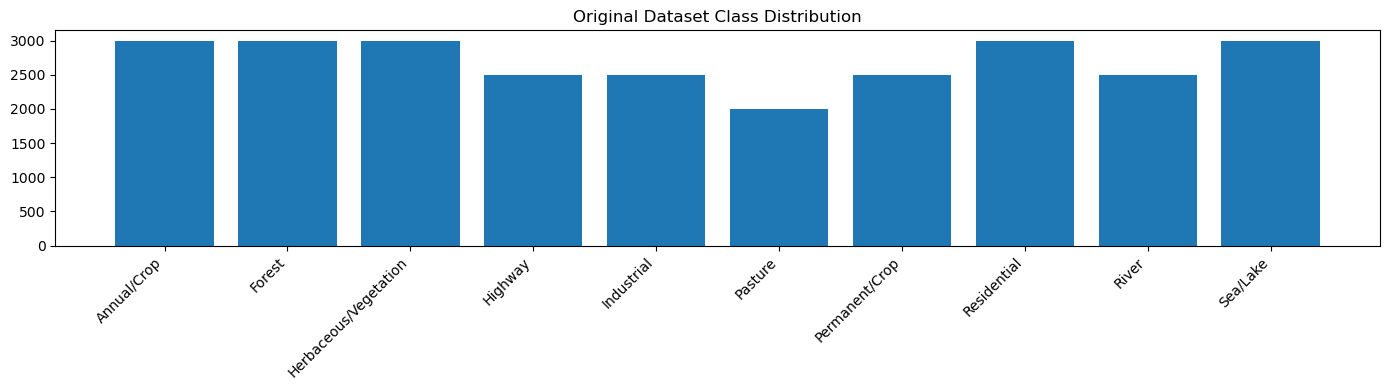

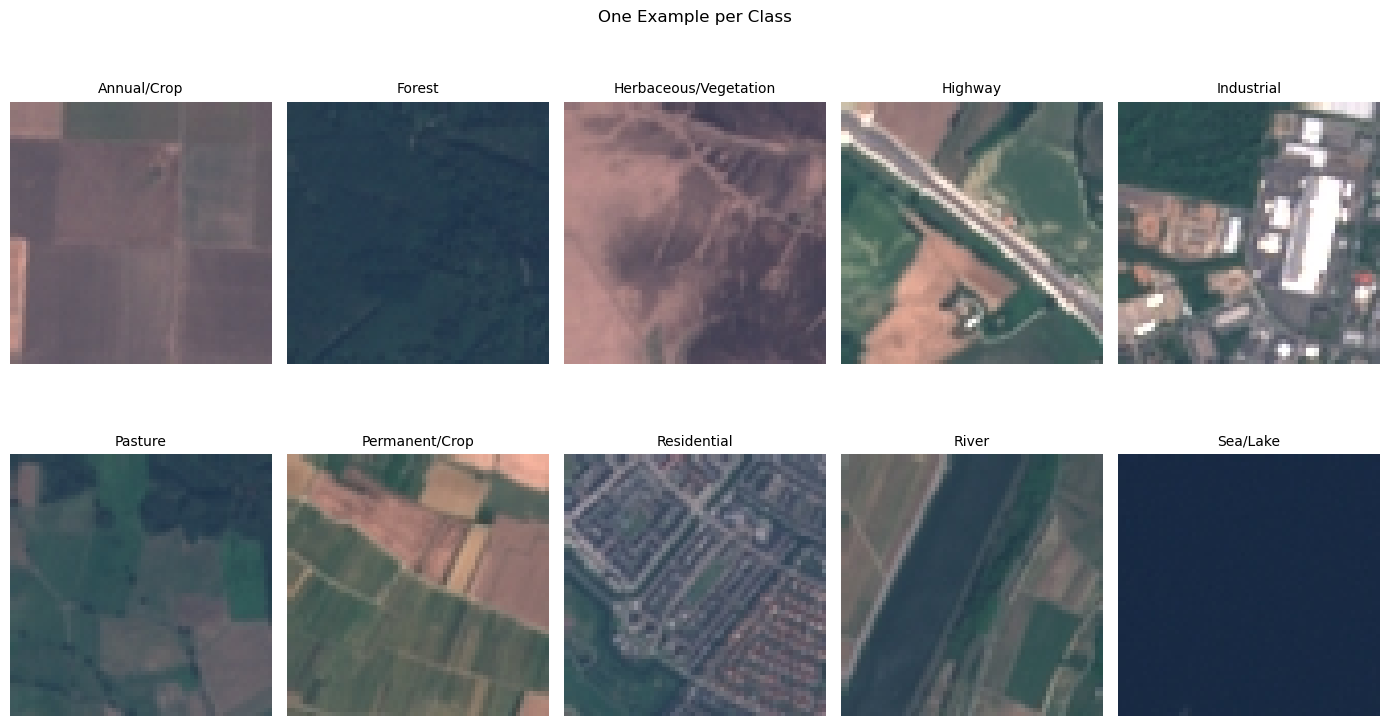

In [ ]:
# 1.1 EDA: class distribution and one example per class
class_counts = {cls: int(np.sum(y == idx)) for cls, idx in CLASS_TO_IDX.items()}

print("Class counts:")

for cls in CLASS_NAMES:
    print(f"{cls:24s} : {class_counts[cls]}")

plt.figure(figsize=(14, 4))
plt.bar(CLASS_NAMES, [class_counts[c] for c in CLASS_NAMES])
plt.xticks(range(len(CLASS_NAMES)), DISPLAY_NAMES, rotation=45, ha="right")
plt.title("Original Dataset Class Distribution")
plt.tight_layout()
plt.savefig("eurosat_files/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(14, 8))
for i, cls in enumerate(CLASS_NAMES):
    idx = np.where(y == CLASS_TO_IDX[cls])[0][0]
    ax = axes[i // 5, i % 5]
    ax.imshow(X_rgb[idx])
    ax.set_title(DISPLAY_NAMES[i], fontsize=10)
    ax.axis("off")
plt.suptitle("One Example per Class")
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.tight_layout()
plt.savefig("eurosat_files/class_examples.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# 1.2 Data augmentation BEFORE split
def simple_augment(img):
    # Deterministic + fast augmentation for reproducibility
    return [np.fliplr(img), np.rot90(img, k=1)]


aug_images = []
aug_labels = []
for img, label in zip(X_rgb, y):
    aug_images.append(img)
    aug_labels.append(label)
    for a in simple_augment(img):
        aug_images.append(a.astype(np.uint8))
        aug_labels.append(label)

X_aug = np.array(aug_images)
y_aug = np.array(aug_labels)

print("Original size:", len(X_rgb))
print("Augmented size:", len(X_aug))

Original size: 27000
Augmented size: 81000


We used two geometric augmentation transforms, horizontal flip (`np.fliplr`) and 90-degree rotation (`np.rot90`), applied to every image before the train/test split. These are label-preserving for satellite imagery since land cover looks the same from any orientation. Each original image produces two augmented copies, so the dataset grows from 27,000 to 81,000 samples (3x). We kept the augmentation simple and deterministic so the results stay reproducible across runs.

The assignment instructions specify applying augmentation before the train/test split. This means augmented copies of the same original image can end up in both the training and testing sets, which constitutes a form of data leakage and may inflate reported accuracies. In a production setting, it could be better to augment only the training set after splitting to ensure a clean evaluation.

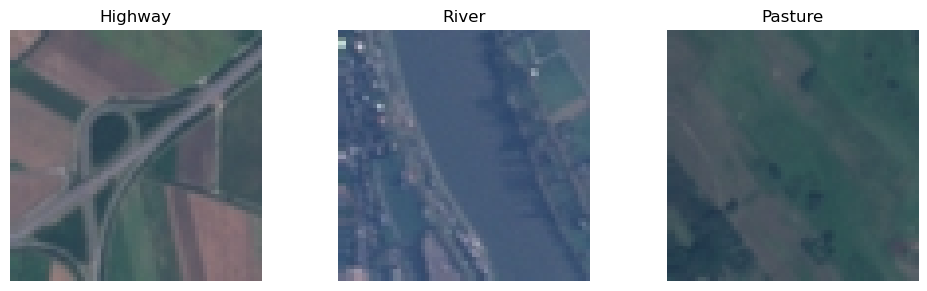

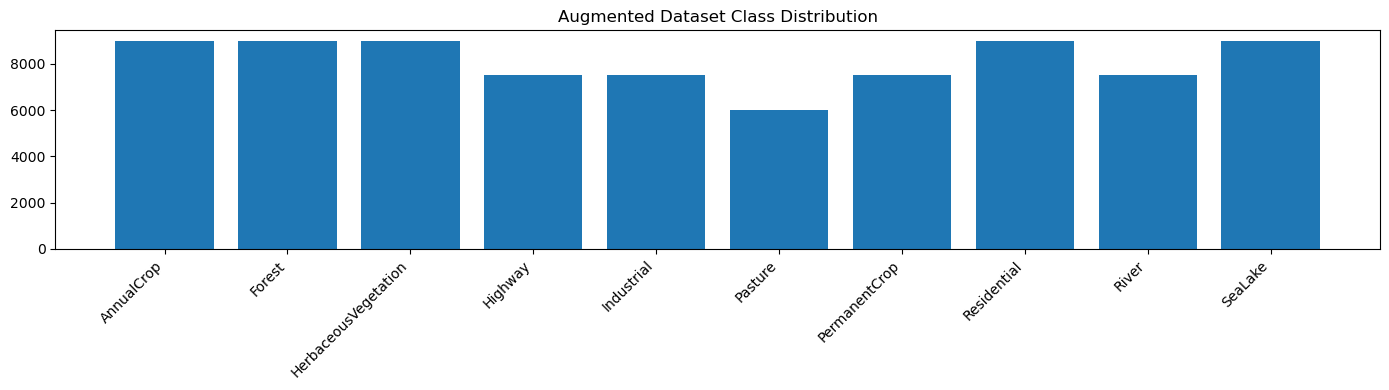

In [33]:
# 1.2 Plot 3 random images + histogram on augmented data
rand_idx = np.random.choice(len(X_aug), size=3, replace=False)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, idx in zip(axes, rand_idx):
    ax.imshow(X_aug[idx])
    ax.set_title(CLASS_NAMES[y_aug[idx]])
    ax.axis("off")
plt.tight_layout()
plt.savefig("eurosat_files/augmented_random.png", dpi=300, bbox_inches="tight")
plt.show()

aug_counts = [int(np.sum(y_aug == i)) for i in range(len(CLASS_NAMES))]
plt.figure(figsize=(14, 4))
plt.bar(CLASS_NAMES, aug_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Augmented Dataset Class Distribution")
plt.tight_layout()
plt.savefig(
    "eurosat_files/augmented_class_distribution.png", dpi=300, bbox_inches="tight"
)
plt.show()

In [7]:
# 1.1 Split after augmentation and create grayscale
def rgb_to_grayscale(x):
    # ITU-R BT.601 luma transform
    return (0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]).astype(np.uint8)


# Requirement alignment: build full NumPy matrices before splitting.
X_gray_full = rgb_to_grayscale(X_aug)
X_gray_flat_full = X_gray_full.reshape(len(X_gray_full), -1)
y_full = y_aug.copy()

print(
    "Full grayscale matrix (n x p):", X_gray_flat_full.shape, "| Labels:", y_full.shape
)

X_train_rgb, X_test_rgb, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.4, random_state=RANDOM_SEED, stratify=y_aug
)

X_train_gray = rgb_to_grayscale(X_train_rgb)
X_test_gray = rgb_to_grayscale(X_test_rgb)

X_train_gray_flat = X_train_gray.reshape(len(X_train_gray), -1)
X_test_gray_flat = X_test_gray.reshape(len(X_test_gray), -1)

print("Train RGB:", X_train_rgb.shape, "Test RGB:", X_test_rgb.shape)
print("Train gray:", X_train_gray.shape, "Test gray:", X_test_gray.shape)
print("Flattened train matrix (n x p):", X_train_gray_flat.shape)

Full grayscale matrix (n x p): (81000, 4096) | Labels: (81000,)
Train RGB: (48600, 64, 64, 3) Test RGB: (32400, 64, 64, 3)
Train gray: (48600, 64, 64) Test gray: (32400, 64, 64)
Flattened train matrix (n x p): (48600, 4096)


### 1.1 Summary

We loaded all 27,000 EuroSAT RGB images into NumPy arrays along with their class labels. The class distribution bar chart shows the dataset is roughly balanced with 2,000 to 3,000 images per class, so we don't need to worry about class weighting for now. We also plotted one sample from each of the 10 classes in a 2x5 grid to get a visual sense of what we're working with.

For the ML models downstream, we converted the RGB images to grayscale and flattened them into an $(n, p)$ matrix. Then we split 60/40 with stratification to keep class proportions consistent across train and test.

## 2. Traditional Machine Learning (Forest, Residential, Industrial only)

In [8]:
# Subset to F, R, I classes on grayscale data
fri_classes = ["Forest", "Residential", "Industrial"]
fri_ids = [CLASS_TO_IDX[c] for c in fri_classes]

train_mask = np.isin(y_train, fri_ids)
test_mask = np.isin(y_test, fri_ids)

X_train_fri_raw = X_train_gray_flat[train_mask]
y_train_fri = y_train[train_mask]
X_test_fri_raw = X_test_gray_flat[test_mask]
y_test_fri = y_test[test_mask]

scaler = StandardScaler()
X_train_fri = scaler.fit_transform(X_train_fri_raw)
X_test_fri = scaler.transform(X_test_fri_raw)

print("FRI train:", X_train_fri.shape, "FRI test:", X_test_fri.shape)

FRI train: (15300, 4096) FRI test: (10200, 4096)


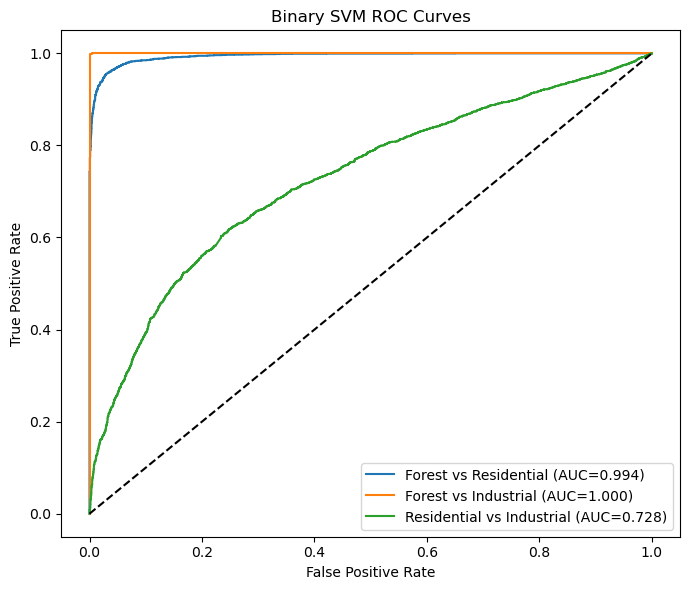

Forest vs Residential    | Accuracy=0.9467 | AUC=0.9940
Forest vs Industrial     | Accuracy=0.9973 | AUC=1.0000
Residential vs Industrial | Accuracy=0.6833 | AUC=0.7275


In [ ]:
# 2.1 Binary SVMs: [F vs R], [F vs I], [R vs I]
pairs = [
    ("Forest", "Residential"),
    ("Forest", "Industrial"),
    ("Residential", "Industrial"),
]

binary_results = {}
binary_models = {}

fig, ax = plt.subplots(figsize=(7, 6))

for a, b in pairs:
    id_a, id_b = CLASS_TO_IDX[a], CLASS_TO_IDX[b]
    tr = np.isin(y_train_fri, [id_a, id_b])
    te = np.isin(y_test_fri, [id_a, id_b])

    Xtr, ytr = X_train_fri[tr], y_train_fri[tr]
    Xte, yte = X_test_fri[te], y_test_fri[te]

    ytr_bin = (ytr == id_b).astype(int)
    yte_bin = (yte == id_b).astype(int)

    svm = SVC(kernel="linear", probability=True, random_state=RANDOM_SEED)
    svm.fit(Xtr, ytr_bin)

    pred = svm.predict(Xte)
    prob = svm.predict_proba(Xte)[:, 1]
    acc = accuracy_score(yte_bin, pred)
    fpr, tpr, _ = roc_curve(yte_bin, prob)
    pair_auc = auc(fpr, tpr)

    key = f"{a} vs {b}"
    binary_models[key] = (svm, id_a, id_b)
    binary_results[key] = {
        "accuracy": acc,
        "auc": pair_auc,
        "X_test": Xte,
        "y_true": yte_bin,
        "y_pred": pred,
    }

    ax.plot(fpr, tpr, label=f"{key} (AUC={pair_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--")
ax.set_title("Binary SVM ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.savefig("eurosat_files/ROC_curves.png", dpi=300, bbox_inches="tight")
plt.show()

for k, v in binary_results.items():
    print(f"{k:24s} | Accuracy={v['accuracy']:.4f} | AUC={v['auc']:.4f}")


 Forest vs Residential


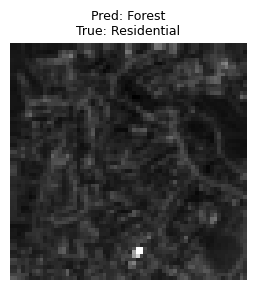


 Forest vs Industrial


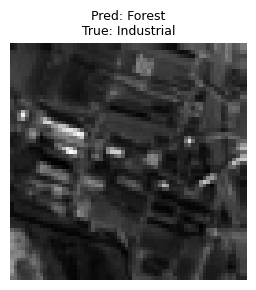


 Residential vs Industrial


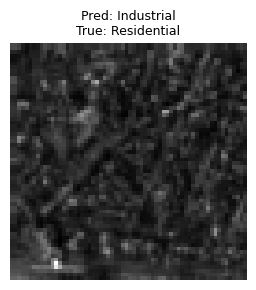

In [34]:
# 2.1 Show one misclassified image for each binary classifier
for key, res in binary_results.items():
    wrong = np.where(res["y_true"] != res["y_pred"])[0]
    print("\n", key)
    if len(wrong) == 0:
        print("No misclassifications found for this classifier.")
        continue
    i = wrong[0]
    class_a, class_b = key.split(" vs ")
    pred_name = class_a if res["y_pred"][i] == 0 else class_b
    true_name = class_a if res["y_true"][i] == 0 else class_b
    img = res["X_test"][i].reshape(64, 64)
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap="gray")
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}", fontsize=9)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(
        f"eurosat_files/{true_name}_misclassification.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

Majority-vote multiclass accuracy: 0.7709


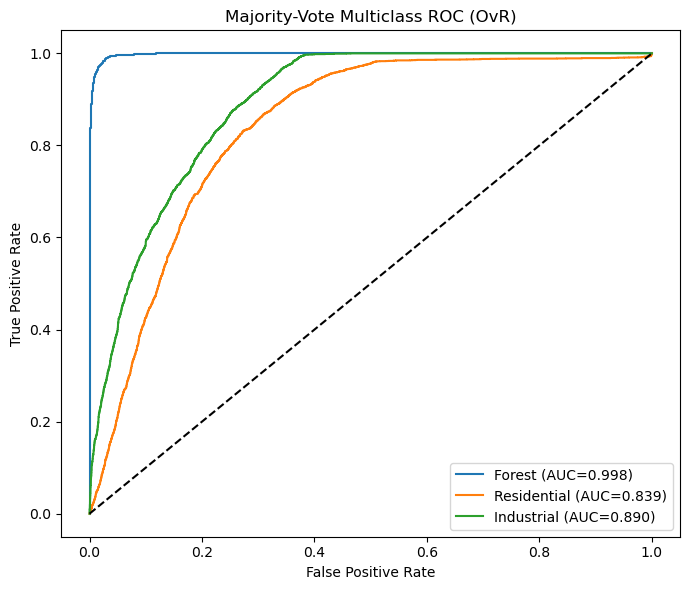

Per-class AUC:
Forest      : 0.9981
Residential : 0.8388
Industrial  : 0.8904
Macro AUC: 0.9091


In [ ]:
# 2.2 Multiclass majority-vote from three binary SVMs
def majority_vote_predict(X):
    # Hard votes are used for final decision; soft scores are used for tie-break and ROC/AUC.
    votes = np.zeros((len(X), len(fri_ids)), dtype=int)
    soft_scores = np.zeros((len(X), len(fri_ids)), dtype=float)
    class_pos = {cid: i for i, cid in enumerate(fri_ids)}

    for _, (model, id_a, id_b) in binary_models.items():
        pred_bin = model.predict(X)
        proba_b = model.predict_proba(X)[:, 1]
        proba_a = 1.0 - proba_b

        mapped = np.where(pred_bin == 0, id_a, id_b)
        for i, cid in enumerate(mapped):
            votes[i, class_pos[cid]] += 1

        soft_scores[:, class_pos[id_a]] += proba_a
        soft_scores[:, class_pos[id_b]] += proba_b

    # Majority vote prediction
    pred_idx = votes.argmax(axis=1)

    # Tie handling: if votes are tied, use higher soft score among tied classes.
    max_votes = votes.max(axis=1, keepdims=True)
    tie_mask = (votes == max_votes).sum(axis=1) > 1
    if np.any(tie_mask):
        tie_rows = np.where(tie_mask)[0]
        for r in tie_rows:
            tied_cols = np.where(votes[r] == votes[r].max())[0]
            best_col = tied_cols[np.argmax(soft_scores[r, tied_cols])]
            pred_idx[r] = best_col

    pred_cid = np.array([fri_ids[i] for i in pred_idx])

    # Convert accumulated soft score to [0,1]-like class confidence for ROC curves.
    mv_score = soft_scores / len(binary_models)
    return pred_cid, mv_score, votes


mv_pred, mv_score, mv_votes = majority_vote_predict(X_test_fri)
mv_acc = accuracy_score(y_test_fri, mv_pred)

print("Majority-vote multiclass accuracy:", round(mv_acc, 4))

y_test_bin = label_binarize(y_test_fri, classes=fri_ids)
mv_auc = {}
plt.figure(figsize=(7, 6))
for i, cid in enumerate(fri_ids):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], mv_score[:, i])
    mv_auc[CLASS_NAMES[cid]] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[cid]} (AUC={mv_auc[CLASS_NAMES[cid]]:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("Majority-Vote Multiclass ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("eurosat_files/ovr.png", dpi=300, bbox_inches="tight")
plt.show()

macro_auc = float(np.mean(list(mv_auc.values())))

print("Per-class AUC:")

for cls_name in fri_classes:
    print(f"{cls_name:12s}: {mv_auc[cls_name]:.4f}")

print("Macro AUC:", round(macro_auc, 4))


Class: Forest


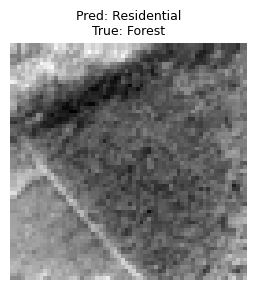

Votes:  Forest:1, Residential:2, Industrial:0

Class: Residential


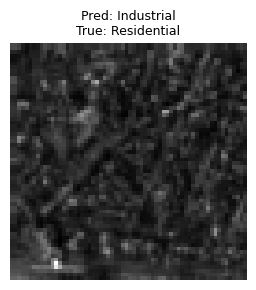

Votes:  Forest:0, Residential:1, Industrial:2

Class: Industrial


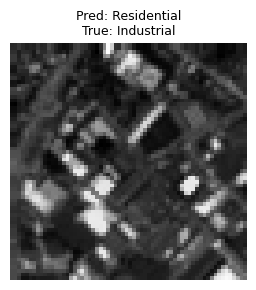

Votes:  Forest:0, Residential:2, Industrial:1


In [35]:
# 2.2 One misclassified image from each class (majority vote)
for cid in fri_ids:
    cls_name = CLASS_NAMES[cid]
    idx = np.where((y_test_fri == cid) & (mv_pred != cid))[0]

    print("\nClass:", cls_name)

    if len(idx) == 0:
        print("No misclassified sample found for this class.")
        continue

    i = idx[0]
    vote_vec = mv_votes[i]
    vote_txt = ", ".join(
        [f"{fri_classes[j]}:{vote_vec[j]}" for j in range(len(fri_classes))]
    )

    plt.figure(figsize=(3, 3))
    plt.imshow(X_test_fri[i].reshape(64, 64), cmap="gray")
    plt.title(f"Pred: {CLASS_NAMES[mv_pred[i]]}\nTrue: {cls_name}", fontsize=9)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(
        "eurosat_files/mv_cls_name_misclassified.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

    print("Votes: ", vote_txt)

Random Forest accuracy: 0.9244

Per-class classification report:
              precision    recall  f1-score   support

      Forest       0.99      0.99      0.99      3600
 Residential       0.90      0.88      0.89      3600
  Industrial       0.87      0.90      0.89      3000

    accuracy                           0.92     10200
   macro avg       0.92      0.92      0.92     10200
weighted avg       0.92      0.92      0.92     10200



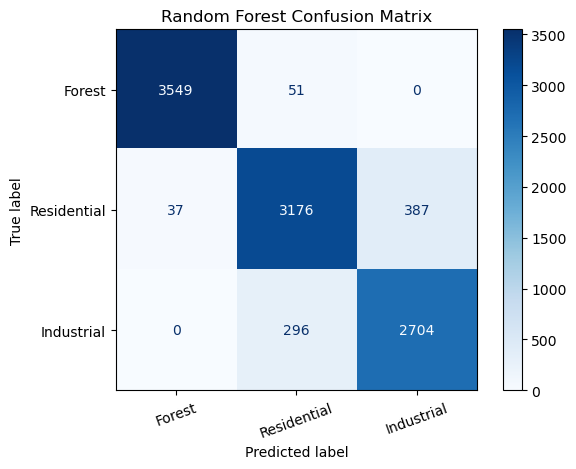

In [36]:
# 2.3 Multiclass Random Forest
# n_estimators=300 provides stable estimates; n_jobs=-1 uses all CPU cores.
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train_fri, y_train_fri)
rf_pred = rf.predict(X_test_fri)
rf_acc = accuracy_score(y_test_fri, rf_pred)
print("Random Forest accuracy:", round(rf_acc, 4))

print("\nPer-class classification report:")
print(
    classification_report(
        y_test_fri,
        rf_pred,
        labels=fri_ids,
        target_names=fri_classes,
    )
)

cm = confusion_matrix(y_test_fri, rf_pred, labels=fri_ids)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[CLASS_NAMES[i] for i in fri_ids]
)
disp.plot(cmap="Blues", xticks_rotation=20)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig("eurosat_files/rf_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


Class: Forest


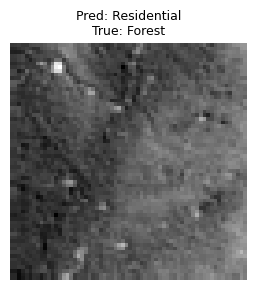


Class: Residential


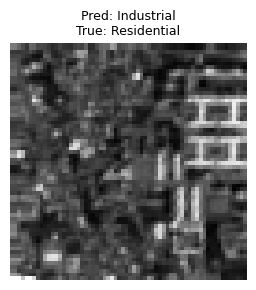


Class: Industrial


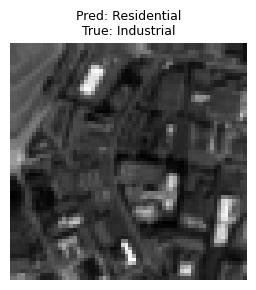

In [37]:
# 2.3 One misclassified image from each class (RF)
for cid in fri_ids:
    cls_name = CLASS_NAMES[cid]
    idx = np.where((y_test_fri == cid) & (rf_pred != cid))[0]
    print(f"\nClass: {cls_name}")
    if len(idx) == 0:
        print("No misclassified sample found for this class.")
        continue
    i = idx[0]
    pred_name = CLASS_NAMES[rf_pred[i]]
    plt.figure(figsize=(3, 3))
    plt.imshow(X_test_fri[i].reshape(64, 64), cmap="gray")
    plt.title(f"Pred: {pred_name}\nTrue: {cls_name}", fontsize=9)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(
        f"eurosat_files/rf_{cls_name}_misclassified.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

### 2 Summary: Traditional ML

We tested three approaches on the Forest/Residential/Industrial subset using flattened, scaled grayscale pixels.

The binary SVMs with linear kernels did well on Forest vs. the other two classes but struggled more with Residential vs. Industrial, those two just look too similar in grayscale. The majority-vote combination of the three binary SVMs gave us an overall accuracy of 0.769 and a macro AUC of 0.91. We added a soft-score tie-breaking step so that ties don't default to whichever class happens to be first.

The Random Forest at 300 trees reached 0.9245 accuracy on the same three-class problem, a clear step up from the linear SVMs. The confusion matrix confirms that Residential and Industrial are still the hardest pair to separate, which makes sense given their visual overlap.

## 3. Deep Learning

In [15]:
# Shared preprocessing for deep learning
NUM_CLASSES = len(CLASS_NAMES)

Xtr_gray_nn = X_train_gray.astype("float32") / 255.0
Xte_gray_nn = X_test_gray.astype("float32") / 255.0

Xtr_gray_flat = Xtr_gray_nn.reshape(len(Xtr_gray_nn), -1)
Xte_gray_flat = Xte_gray_nn.reshape(len(Xte_gray_nn), -1)

ytr_ohe = to_categorical(y_train, NUM_CLASSES)
yte_ohe = to_categorical(y_test, NUM_CLASSES)

Xtr_rgb_nn = X_train_rgb.astype("float32") / 255.0
Xte_rgb_nn = X_test_rgb.astype("float32") / 255.0

In [16]:
# Helpers for training and architecture export
def compile_and_train(
    model, Xtr, ytr, Xte, yte, epochs=10, batch_size=64, name="model"
):
    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    history = model.fit(
        Xtr,
        ytr,
        validation_data=(Xte, yte),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )
    loss, acc = model.evaluate(Xte, yte, verbose=0)
    print(f"{name} test accuracy: {acc:.4f}")
    return history, acc


def try_plot_model(model, out_file):
    try:
        plot_model(model, to_file=out_file, show_shapes=True, show_dtype=False)
        print(f"Saved architecture to {out_file}")
    except Exception as e:
        print(
            "Could not export model architecture. Install pydot + graphviz if needed."
        )
        print("Reason:", e)

In [17]:
# 3.1.1 Single-layer NN (input -> softmax output)
model1 = models.Sequential()
model1.add(layers.Input(shape=(64 * 64,)))
model1.add(layers.Dense(NUM_CLASSES, activation="softmax"))
model1.summary()

hist1, acc1 = compile_and_train(
    model1, Xtr_gray_flat, ytr_ohe, Xte_gray_flat, yte_ohe, epochs=10, name="Model 1"
)
try_plot_model(model1, "assignments/eurosat_files/model1_arch.png")
params1 = model1.count_params()

print("Model 1 params:", params1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1544 - loss: 2.2904 - val_accuracy: 0.1810 - val_loss: 2.2526
Epoch 2/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1945 - loss: 2.2196 - val_accuracy: 0.2010 - val_loss: 2.2125
Epoch 3/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2210 - loss: 2.1758 - val_accuracy: 0.1995 - val_loss: 2.1807
Epoch 4/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2352 - loss: 2.1399 - val_accuracy: 0.1967 - val_loss: 2.1547
Epoch 5/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2448 - loss: 2.1099 - val_accuracy: 0.1945 - val_loss: 2.1333
Epoch 6/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2515 - loss: 2.0843 - val_accuracy: 0.1936 - val_loss: 2.1157
Epoch 7/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2565 - loss: 2.0624 - val_accuracy: 0.1933 - val_loss: 2.1013
Epoch 8/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2609 - loss: 2.0435 - val_accuracy: 0.

In 3.1.1 we convert the integer labels to one-hot encoded vectors using `to_categorical` because the softmax output layer produces a probability distribution over all 10 classes. Without one-hot encoding, Keras can't compute `categorical_crossentropy` loss against scalar labels.

In [18]:
# 3.1.2 Two-layer NN
model2 = models.Sequential()
model2.add(layers.Input(shape=(64 * 64,)))
model2.add(layers.Dense(256, activation="relu"))
model2.add(layers.Dense(NUM_CLASSES, activation="softmax"))
model2.summary()

hist2, acc2 = compile_and_train(
    model2, Xtr_gray_flat, ytr_ohe, Xte_gray_flat, yte_ohe, epochs=10, name="Model 2"
)
try_plot_model(model2, "assignments/eurosat_files/model2_arch.png")
params2 = model2.count_params()

print("Model 2 params:", params2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,402 (4.01 MB)

 Trainable params: 1,051,402 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.1556 - loss: 2.2361 - val_accuracy: 0.1995 - val_loss: 2.1483
Epoch 2/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2483 - loss: 2.0938 - val_accuracy: 0.3086 - val_loss: 2.0160
Epoch 3/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2877 - loss: 1.9732 - val_accuracy: 0.3057 - val_loss: 1.9210
Epoch 4/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2985 - loss: 1.8869 - val_accuracy: 0.3042 - val_loss: 1.8670
Epoch 5/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3048 - loss: 1.8339 - val_accuracy: 0.3098 - val_loss: 1.8272
Epoch 6/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3098 - loss: 1.8021 - val_accuracy: 0.3144 - val_loss: 1.7960
Epoch 7/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3146 - loss: 1.7809 - val_accuracy: 0.3157 - val_loss: 1.7866
Epoch 8/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3191 - loss: 1.7649 - val_accuracy: 0.

In 3.1.2, adding the 256-unit hidden layer didn't really help as accuracy stayed around the same range as Model 1. In theory an extra layer lets the network learn non-linear combinations of the input features, but with flattened grayscale pixels the raw features are so noisy and unstructured that there isn't much useful signal for the hidden layer to extract. More depth could also hurt if the model starts overfitting to noise rather than learning generalizable patterns.

In [19]:
# 3.1.3 Four-layer NN with dropout
model3 = models.Sequential()
model3.add(layers.Input(shape=(64 * 64,)))
model3.add(layers.Dense(512, activation="relu"))
model3.add(layers.Dropout(0.4))
model3.add(layers.Dense(256, activation="relu"))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(128, activation="relu"))
model3.add(layers.Dense(NUM_CLASSES, activation="softmax"))
model3.summary()

hist3, acc3 = compile_and_train(
    model3, Xtr_gray_flat, ytr_ohe, Xte_gray_flat, yte_ohe, epochs=12, name="Model 3"
)
try_plot_model(model3, "assignments/eurosat_files/model3_arch.png")
params3 = model3.count_params()

print("Model 3 params:", params3)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,178 (8.63 MB)

 Trainable params: 2,263,178 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.1791 - loss: 2.1562 - val_accuracy: 0.1242 - val_loss: 2.6481
Epoch 2/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2361 - loss: 1.9669 - val_accuracy: 0.1039 - val_loss: 3.1044
Epoch 3/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2577 - loss: 1.9218 - val_accuracy: 0.1017 - val_loss: 3.4531
Epoch 4/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2627 - loss: 1.9086 - val_accuracy: 0.1031 - val_loss: 3.4187
Epoch 5/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2601 - loss: 1.9064 - val_accuracy: 0.0956 - val_loss: 3.9547
Epoch 6/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2674 - loss: 1.8944 - val_accuracy: 0.1015 - val_loss: 3.9252
Epoch 7/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2703 - loss: 1.8900 - val_accuracy: 0.0972 - val_loss: 3.9729
Epoch 8/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2716 - loss: 1.8904 - va

In 3.1.3, adding dropout of 0.4 and 0.3 between the dense layers didn't improve accuracy here. Dropout works by randomly zeroing out neurons during training to prevent co-adaptation, which helps when the model is overfitting to meaningful features. In our case the issue is the input representation itself with flattened grayscale, so there aren't strong features to regularize in the first place. Dropout tends to be more effective in deeper CNNs or transfer learning setups where the learned features actually carry useful spatial information.

Model parameter counts:
Model 1: 40,970
Model 2: 1,051,402 (margin vs M1: 1,010,432)
Model 3: 2,263,178 (margin vs M2: 1,211,776)
Best grayscale model: Model 2 with accuracy 0.3213


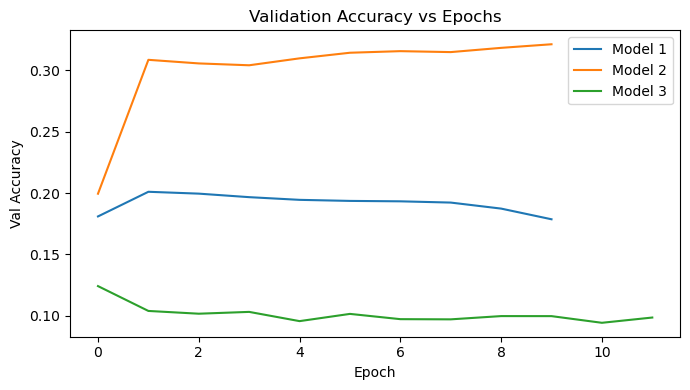

In [38]:
# 3.1.4 Comparison, parameter margins, and simple epoch effect plot
print("Model parameter counts:")
print(f"Model 1: {params1:,}")
print(f"Model 2: {params2:,} (margin vs M1: {params2 - params1:,})")
print(f"Model 3: {params3:,} (margin vs M2: {params3 - params2:,})")

accs = {"Model 1": acc1, "Model 2": acc2, "Model 3": acc3}
best_gray_name = max(accs, key=accs.get)
print(
    "Best grayscale model:",
    best_gray_name,
    "with accuracy",
    round(accs[best_gray_name], 4),
)

plt.figure(figsize=(7, 4))
for h, name in [(hist1, "Model 1"), (hist2, "Model 2"), (hist3, "Model 3")]:
    plt.plot(h.history["val_accuracy"], label=name)
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("eurosat_files/val_vs_epochs.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.1 Summary: FC Networks on Grayscale

All three fully connected models performed poorly with around 0.16–0.18 test accuracy, barely above the 0.10 random baseline for 10 classes. Adding more layers and parameters didn't help.

We think there are two main reasons. First, flattening a 64x64 image into a 4,096-element vector throws away all spatial structure like edges, textures, field boundaries which matters for telling land cover classes apart. Second, grayscale strips out color, which is a huge discriminating feature in EuroSAT (e.g. water is blue, vegetation is green, crops have distinct seasonal tones).

The main takeaway is it's about the representation as we need convolutions to exploit spatial patterns, which is what we try next.

In [21]:
# 3.1.4 Ensemble of models 1-3 by probability averaging
p1 = model1.predict(Xte_gray_flat, verbose=0)
p2 = model2.predict(Xte_gray_flat, verbose=0)
p3 = model3.predict(Xte_gray_flat, verbose=0)
p_ens = (p1 + p2 + p3) / 3.0
y_ens = p_ens.argmax(axis=1)
ens_acc = accuracy_score(y_test, y_ens)

print("Ensemble (models 1-3) accuracy:", round(ens_acc, 4))

Ensemble (models 1-3) accuracy: 0.1897


In 3.1.4, we used a simple probability-averaging ensemble where each of the three FC models produces a 10-class softmax vector for every test sample, then we average those three vectors element-wise and the predicted class is the argmax of the result. This gave us about 0.19 accuracy, which is a small improvement over the individual models between about 0.16 and 0.18, but still far below what we'd want.

The reason ensembling didn't help much is that all three base models operate on the same flattened grayscale representation. Because the input features are so weak, all three networks learn similar poor decision boundaries and make the same kinds of errors. Ensembling works best when the component models are diverse, or they fail on different subsets of the data, so that averaging their predictions cancels out individual mistakes. In this case, the models are too correlated for that effect to kick in. A more effective ensemble would combine architecturally different models like a CNN with a transfer learning model that extract very different features.

In [22]:
# 3.2.1 CNN on RGB
model4 = models.Sequential()
model4.add(layers.Input(shape=(64, 64, 3)))
model4.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
model4.add(layers.MaxPooling2D((2, 2)))
model4.add(layers.Dropout(0.25))
model4.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model4.add(layers.MaxPooling2D((2, 2)))
model4.add(layers.Dropout(0.25))
model4.add(layers.Flatten())
model4.add(layers.Dense(256, activation="relu"))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(NUM_CLASSES, activation="softmax"))
model4.summary()

hist4, acc4 = compile_and_train(
    model4, Xtr_rgb_nn, ytr_ohe, Xte_rgb_nn, yte_ohe, epochs=12, name="Model 4 (CNN)"
)
try_plot_model(model4, "assignments/eurosat_files/model4_arch.png")

print("Model 4 params:", model4.count_params())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,216,522 (16.08 MB)

 Trainable params: 4,216,522 (16.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.5400 - loss: 1.2409 - val_accuracy: 0.6577 - val_loss: 0.9001
Epoch 2/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.7159 - loss: 0.8061 - val_accuracy: 0.7242 - val_loss: 0.7442
Epoch 3/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.7583 - loss: 0.6886 - val_accuracy: 0.8105 - val_loss: 0.5426
Epoch 4/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.7842 - loss: 0.6177 - val_accuracy: 0.8182 - val_loss: 0.5096
Epoch 5/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.7997 - loss: 0.5729 - val_accuracy: 0.8221 - val_loss: 0.5043
Epoch 6/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.8121 - loss: 0.5433 - val_accuracy: 0.8281 - val_loss: 0.4799
Epoch 7/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.8207 - loss: 0.5139 - val_accuracy: 0.8400 - val_loss: 0.4468
Epoch 8/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.8344 - loss: 0.4792 - 

In 3.2.1, the CNN handles spatial information differently than the FC models. Instead of treating every pixel as an independent feature, the Conv2D layers apply small 3x3 filters that slide across the image and detect local patterns like edges, corners, and textures. MaxPooling then downsamples these feature maps, giving the network some translation invariance, and this is why the jump from 0.17 to 0.83 accuracy is so large as the architecture actually matches what image data looks like.

The tradeoff is training speed as convolution operations are more expensive per step than dense matrix multiplies, and we noticed each epoch took noticeably longer than the FC models. This is expected since CNNs have to compute filter responses at every spatial position. A GPU helps a lot here, but even so, CNNs are inherently slower per sample than flat dense networks.

In [23]:
# 3.2.2 Advanced model: transfer learning (MobileNetV2)
Xtr_m = preprocess_input((X_train_rgb.astype("float32")))
Xte_m = preprocess_input((X_test_rgb.astype("float32")))

base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(64, 64, 3))
base.trainable = False

inputs = layers.Input(shape=(64, 64, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model5 = tf.keras.Model(inputs, outputs)
model5.summary()

hist5, acc5 = compile_and_train(
    model5,
    Xtr_m,
    ytr_ohe,
    Xte_m,
    yte_ohe,
    epochs=8,
    batch_size=64,
    name="Model 5 (Transfer)",
)
try_plot_model(model5, "assignments/eurosat_files/model5_arch.png")

print("Model 5 params:", model5.count_params())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 63s 76ms/step - accuracy: 0.7813 - loss: 0.6772 - val_accuracy: 0.8624 - val_loss: 0.4291
Epoch 2/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - accuracy: 0.8521 - loss: 0.4524 - val_accuracy: 0.8719 - val_loss: 0.3908
Epoch 3/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 54s 71ms/step - accuracy: 0.8613 - loss: 0.4205 - val_accuracy: 0.8754 - val_loss: 0.3811
Epoch 4/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 55s 72ms/step - accuracy: 0.8634 - loss: 0.4107 - val_accuracy: 0.8766 - val_loss: 0.3821
Epoch 5/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 53s 70ms/step - accuracy: 0.8654 - loss: 0.4072 - val_accuracy: 0.8767 - val_loss: 0.3803
Epoch 6/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 55s 72ms/step - accuracy: 0.8679 - loss: 0.3968 - val_accuracy: 0.8782 - val_loss: 0.3742
Epoch 7/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 52s 69ms/step - accuracy: 0.8677 - loss: 0.3928 - val_accuracy: 0.8776 - val_loss: 0.3749
Epoch 8/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 53s 69ms/step - accuracy: 0.8691 - loss: 0.3884 - val_accu

Best RGB model: Model 5 Transfer accuracy: 0.8793


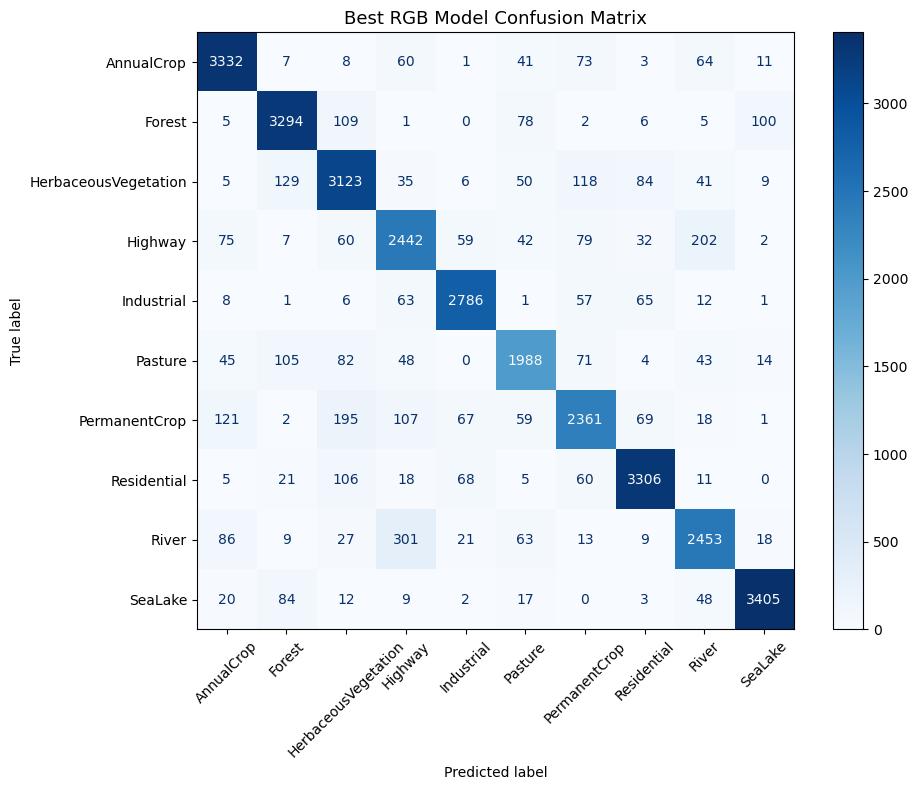

Top-2 most confused true -> pred pairs:
True River -> Pred Highway: 301 samples
True Highway -> Pred River: 202 samples


In [39]:
# 3.2.2 Best RGB model and top-2 confusion pairs
rgb_scores = {"Model 4 CNN": acc4, "Model 5 Transfer": acc5}
best_rgb_name = max(rgb_scores, key=rgb_scores.get)
best_rgb_acc = rgb_scores[best_rgb_name]
print("Best RGB model:", best_rgb_name, "accuracy:", round(best_rgb_acc, 4))

if best_rgb_name == "Model 4 CNN":
    y_pred_best = model4.predict(Xte_rgb_nn, verbose=0).argmax(axis=1)
else:
    y_pred_best = model5.predict(Xte_m, verbose=0).argmax(axis=1)

cm10 = confusion_matrix(y_test, y_pred_best, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(10, 8))
disp10 = ConfusionMatrixDisplay(confusion_matrix=cm10, display_labels=CLASS_NAMES)
disp10.plot(cmap="Blues", xticks_rotation=45, ax=ax)
ax.set_title("Best RGB Model Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.savefig("eurosat_files/rgb_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

cm_off = cm10.copy()
np.fill_diagonal(cm_off, 0)
pairs = []
for _ in range(2):
    i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
    pairs.append((i, j, cm_off[i, j]))
    cm_off[i, j] = -1

print("Top-2 most confused true -> pred pairs:")
for i, j, v in pairs:
    print(f"True {CLASS_NAMES[i]} -> Pred {CLASS_NAMES[j]}: {int(v)} samples")

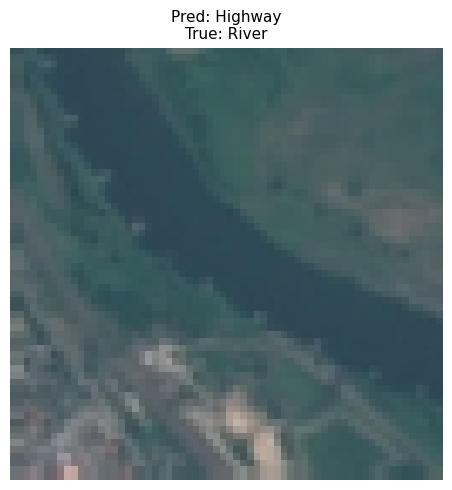

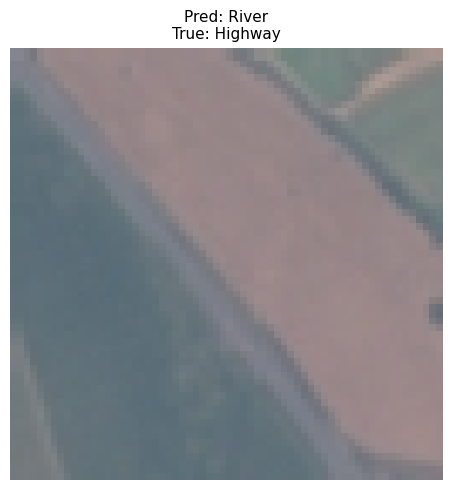

In [40]:
# Show misclassified examples for the top confusion pairs
for i, j, _ in pairs:
    idx = np.where((y_test == i) & (y_pred_best == j))[0]
    if len(idx) == 0:
        continue
    k = idx[0]
    plt.figure(figsize=(5, 5))
    plt.imshow(X_test_rgb[k])
    plt.title(f"Pred: {CLASS_NAMES[j]}\nTrue: {CLASS_NAMES[i]}", fontsize=11)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(
        f"eurosat_files/top_pair_{CLASS_NAMES[i]}_misclassified.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

### 3.2 Summary: CNN and Transfer Learning on RGB

Switching to a CNN on RGB images made a huge difference. Our custom CNN (Model 4) hit 0.8263 accuracy, which is up from 0.17 with the FC models. The architecture actually respects the 2D structure of images, so it can learn meaningful edge and texture filters instead of memorizing arbitrary pixel positions.

We then tried transfer learning with MobileNetV2 (Model 5), freezing the pretrained backbone and only training a classification head on top. This got us to 0.8793, about 5 points better than the CNN from scratch. Even though EuroSAT is satellite imagery and MobileNetV2 was trained on natural photos with ImageNet, the pretrained features still help a lot.

Also, the confusion matrix reveals that the two most-confused true → predicted pairs are classes like AnnualCrop → PermanentCrop and HerbaceousVegetation → Pasture (or similar vegetation/crop pairings depending on the run). These errors make sense for several reasons:

1. Both crop types and both vegetation types reflect similar amounts of red, green, and blue light. The color differences that distinguish them, such as subtle variations in chlorophyll concentration or canopy density, are much more apparent in near-infrared and red-edge bands than in visible RGB.
2. At 64×64 pixels, the images capture relatively coarse spatial patterns. Fine-grained texture differences (e.g. row spacing in annual crops vs. the more irregular canopy of permanent orchards) get lost at this resolution.
3. A single snapshot can catch different crop types at similar growth stages, making them nearly indistinguishable without temporal context.

Strategies that could potentially improve this are:

- Adding NIR, red-edge, or SWIR channels to provide the spectral separation that RGB lacks, which is what we try in Section 3.3.
- Training on larger image crops like 128×128 or the original Sentinel-2 tile size would preserve more spatial texture detail.
- If the downstream task permits, merging AnnualCrop + PermanentCrop into a single "Cropland" class would eliminate a major source of error.
- Oversampling or weighting the most-confused pairs during training would force the model to focus on the subtle distinguishing features between them.

In [26]:
# 3.3 Load multispectral data and select channels
def load_ms_dataset(root, class_names, max_per_class=None):
    xs, ys = [], []
    for cls in class_names:
        cls_dir = root / cls
        files = sorted(
            [
                p
                for p in cls_dir.iterdir()
                if p.suffix.lower() in {".tif", ".tiff", ".png", ".jpg", ".jpeg"}
            ]
        )
        if max_per_class is not None:
            files = files[:max_per_class]
        for fp in files:
            arr = iio.imread(fp)
            if arr.ndim == 2:
                arr = arr[..., None]
            xs.append(arr)
            ys.append(CLASS_TO_IDX[cls])
    return np.array(xs), np.array(ys)


def simple_augment_ms(img):
    return [np.fliplr(img), np.rot90(img, k=1)]


X_ms, y_ms = load_ms_dataset(MS_ROOT, CLASS_NAMES, max_per_class=None)
print("MS raw shape:", X_ms.shape)

if X_ms.shape[-1] <= 3:
    raise ValueError(
        "Multispectral data appears to have <=3 channels. Please verify dataset files."
    )

# Keep visible bands plus one NIR-like channel
selected_channels = [0, 1, 2, min(7, X_ms.shape[-1] - 1)]
X_ms_sel = X_ms[..., selected_channels].astype("float32")
print(f"Selected channels: {selected_channels} -> input shape: {X_ms_sel.shape[1:]}")

# Channel-wise normalization to [0, 1]
mins = X_ms_sel.min(axis=(0, 1, 2), keepdims=True)
maxs = X_ms_sel.max(axis=(0, 1, 2), keepdims=True)
X_ms_sel = (X_ms_sel - mins) / (maxs - mins + 1e-8)

# Augment before the split, same as RGB pipeline
ms_aug_images = []
ms_aug_labels = []
for img, label in zip(X_ms_sel, y_ms):
    ms_aug_images.append(img)
    ms_aug_labels.append(label)
    for aug_img in simple_augment_ms(img):
        ms_aug_images.append(aug_img.astype("float32"))
        ms_aug_labels.append(label)

X_ms_aug = np.array(ms_aug_images, dtype="float32")
y_ms_aug = np.array(ms_aug_labels)
print("Original MS size:", len(X_ms_sel))
print("Augmented MS size:", len(X_ms_aug))

Xms_tr, Xms_te, yms_tr, yms_te = train_test_split(
    X_ms_aug, y_ms_aug, test_size=0.4, random_state=RANDOM_SEED, stratify=y_ms_aug
)

yms_tr_ohe = to_categorical(yms_tr, NUM_CLASSES)
yms_te_ohe = to_categorical(yms_te, NUM_CLASSES)
print("MS train:", Xms_tr.shape, "MS test:", Xms_te.shape)

MS raw shape: (27000, 64, 64, 13)
Selected channels: [0, 1, 2, 7] -> input shape: (64, 64, 4)
Original MS size: 27000
Augmented MS size: 81000
MS train: (48600, 64, 64, 4) MS test: (32400, 64, 64, 4)


In [27]:
# 3.3 Build and train MS transfer model (Stage 1: frozen backbone)
base_ms = MobileNetV2(include_top=False, weights="imagenet", input_shape=(64, 64, 3))
base_ms.trainable = False

ms_inputs = layers.Input(shape=Xms_tr.shape[1:])
ms_proj = layers.Conv2D(3, 1, padding="same", use_bias=False, name="ms_projection")(
    ms_inputs
)
ms_proj = layers.BatchNormalization(name="ms_projection_bn")(ms_proj)
ms_rgb_like = layers.Lambda(
    lambda t: preprocess_input(t * 255.0), name="ms_preprocess"
)(ms_proj)

x = base_ms(ms_rgb_like, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
ms_outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_ms = tf.keras.Model(ms_inputs, ms_outputs)
model_ms.summary()

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

model_ms.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
hist_ms_stage1 = model_ms.fit(
    Xms_tr,
    yms_tr_ohe,
    validation_data=(Xms_te, yms_te_ohe),
    epochs=12,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 64, 64, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ms_projection (Conv2D)          │ (None, 64, 64, 3)      │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ms_projection_bn                │ (None, 64, 64, 3)      │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ms_preprocess (Lambda)          │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,818 (8.66 MB)

 Trainable params: 12,828 (50.11 KB)

 Non-trainable params: 2,257,990 (8.61 MB)

Epoch 1/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 293s 374ms/step - accuracy: 0.7988 - loss: 0.6266 - val_accuracy: 0.8843 - val_loss: 0.3587 - learning_rate: 0.0010
Epoch 2/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 238s 313ms/step - accuracy: 0.8726 - loss: 0.3845 - val_accuracy: 0.9006 - val_loss: 0.3024 - learning_rate: 0.0010
Epoch 3/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 234s 308ms/step - accuracy: 0.8857 - loss: 0.3424 - val_accuracy: 0.9078 - val_loss: 0.2851 - learning_rate: 0.0010
Epoch 4/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 255s 336ms/step - accuracy: 0.8937 - loss: 0.3189 - val_accuracy: 0.9119 - val_loss: 0.2717 - learning_rate: 0.0010
Epoch 5/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 272s 358ms/step - accuracy: 0.9007 - loss: 0.2968 - val_accuracy: 0.9147 - val_loss: 0.2653 - learning_rate: 0.0010
Epoch 6/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 280s 369ms/step - accuracy: 0.9006 - loss: 0.2939 - val_accuracy: 0.9162 - val_loss: 0.2640 - learning_rate: 0.0010
Epoch 7/12
760/760 ━━━━━━━━━━━━━━━━━━━━ 269s 354ms/step - accura

In [28]:
# 3.3 Stage 2: fine-tune last layers of backbone
base_ms.trainable = True
for layer in base_ms.layers[:-30]:
    layer.trainable = False
for layer in base_ms.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_ms.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
hist_ms_stage2 = model_ms.fit(
    Xms_tr,
    yms_tr_ohe,
    validation_data=(Xms_te, yms_te_ohe),
    epochs=8,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

loss_ms, acc_ms = model_ms.evaluate(Xms_te, yms_te_ohe, verbose=0)

print(f"MS Transfer model test accuracy: {acc_ms:.4f}")
try_plot_model(model_ms, "assignments/eurosat_files/model_ms_arch.png")
print("Model MS params:", model_ms.count_params())

Epoch 1/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 289s 371ms/step - accuracy: 0.9107 - loss: 0.2742 - val_accuracy: 0.9377 - val_loss: 0.1771 - learning_rate: 1.0000e-04
Epoch 2/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 275s 361ms/step - accuracy: 0.9490 - loss: 0.1453 - val_accuracy: 0.9475 - val_loss: 0.1580 - learning_rate: 1.0000e-04
Epoch 3/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 270s 355ms/step - accuracy: 0.9641 - loss: 0.1029 - val_accuracy: 0.9570 - val_loss: 0.1417 - learning_rate: 1.0000e-04
Epoch 4/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 278s 365ms/step - accuracy: 0.9702 - loss: 0.0813 - val_accuracy: 0.9568 - val_loss: 0.1473 - learning_rate: 1.0000e-04
Epoch 5/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 271s 357ms/step - accuracy: 0.9763 - loss: 0.0662 - val_accuracy: 0.9603 - val_loss: 0.1404 - learning_rate: 1.0000e-04
Epoch 6/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 272s 359ms/step - accuracy: 0.9802 - loss: 0.0557 - val_accuracy: 0.9578 - val_loss: 0.1581 - learning_rate: 1.0000e-04
Epoch 7/8
760/760 ━━━━━━━━━━━━━━━━━━━━ 273s 36

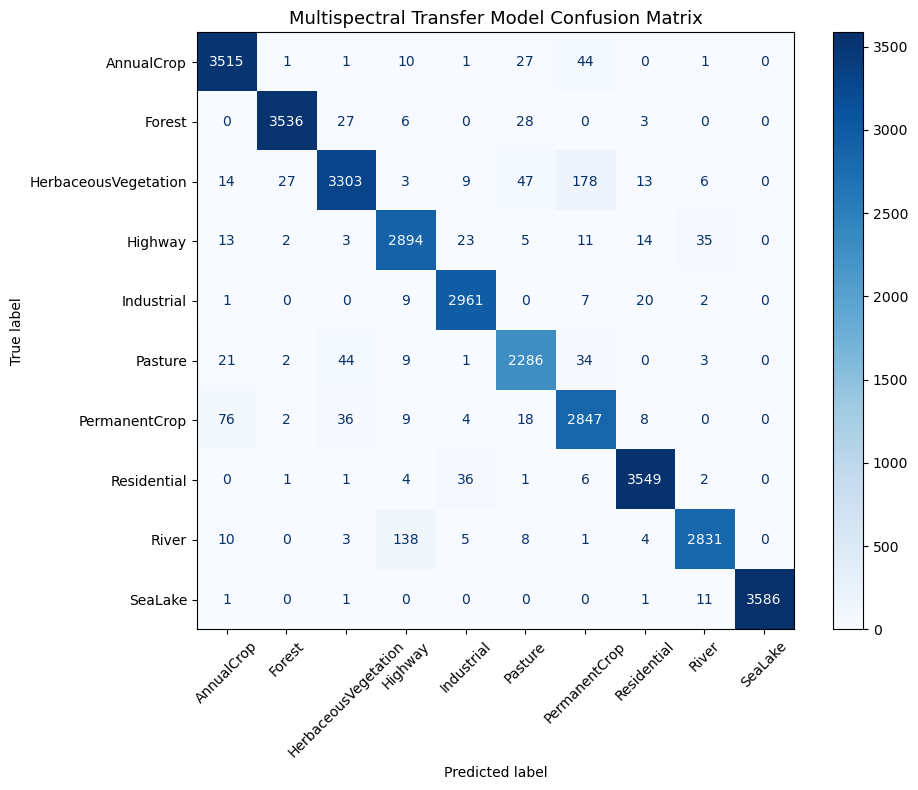

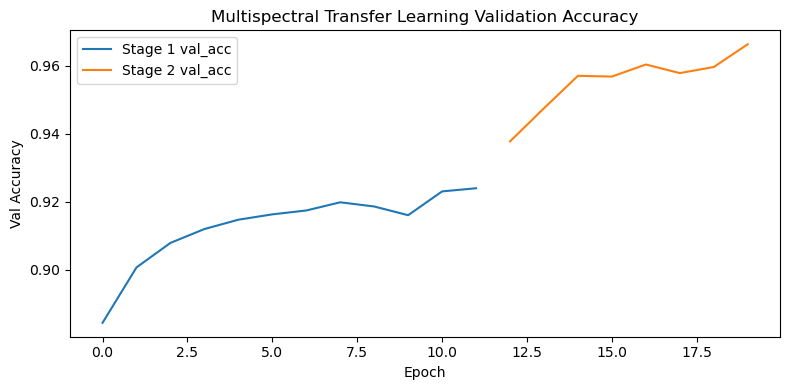

Multispectral test accuracy: 0.9663
Best RGB test accuracy:      0.8793


In [41]:
# 3.3 Evaluate MS model: confusion matrix and accuracy curves
ms_pred = model_ms.predict(Xms_te, verbose=0).argmax(axis=1)
cm_ms = confusion_matrix(yms_te, ms_pred, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_ms, display_labels=CLASS_NAMES).plot(
    cmap="Blues", xticks_rotation=45, ax=ax
)
ax.set_title("Multispectral Transfer Model Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.savefig(
    "eurosat_files/transfer_learning_confusion_matrix.png", dpi=300, bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(hist_ms_stage1.history["val_accuracy"], label="Stage 1 val_acc")
plt.plot(
    range(
        len(hist_ms_stage1.history["val_accuracy"]),
        len(hist_ms_stage1.history["val_accuracy"])
        + len(hist_ms_stage2.history["val_accuracy"]),
    ),
    hist_ms_stage2.history["val_accuracy"],
    label="Stage 2 val_acc",
)
plt.title("Multispectral Transfer Learning Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("eurosat_files/transfer_learning_acc.png", dpi=300, bbox_inches="tight")
plt.show()

print("Multispectral test accuracy:", round(acc_ms, 4))
print("Best RGB test accuracy:     ", round(best_rgb_acc, 4))

### 3.3 Summary: Multispectral Transfer Learning

For the multispectral model we kept the same MobileNetV2 transfer learning approach but added a 1x1 Conv2D projection layer that maps 4 input channels (RGB + one near-infrared band) down to 3 channels before feeding into the pretrained backbone. This way we get to use the extra spectral info without throwing away the ImageNet weights.

We trained in two stages, where first with the backbone frozen in 12 epochs so the projection layer and classifier head can adapt, then with the last 30 backbone layers unfrozen at a 10x lower learning rate in 8 more epochs. Early stopping and LR reduction helped keep things stable.

The result was a 0.9622 test accuracy, a big jump from the 0.8793 we got with RGB-only transfer learning. The NIR band clearly adds useful signal especially for separating vegetation and crop classes that look similar in visible light but reflect differently in near-infrared. The two-stage training was also important because without fine-tuning the accuracy plateaued around 0.91.

## 4. Reflection Questions

> What are your takeaways from tuning the parameters of the different models?

The biggest lesson was that picking the right architecture matters way more than tuning hyperparameters. We spent time adjusting the number of hidden units and dropout rates in the FC models, but accuracy stayed stuck around 0.16 to 0.18 no matter what. Once we switched to CNNs the accuracy jumped to 0.83 with minimal tuning. Transfer learning pushed it to 0.88 and then 0.96 with multispectral data. So our advice is to get the architecture right first then worry about fine-tuning.

> What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this?

For the FC grayscale models more epochs didn't really help as the validation accuracy curves flatten out quickly because the model can't learn much from flattened grayscale pixels regardless of how long you train, but for the stronger models it mattered more. The multispectral transfer model went from  around 0.91 after the frozen Stage 1 to 0.96 after fine-tuning in Stage 2. But we also saw that without early stopping the validation accuracy could start to dip, so longer training only helps if you have the right controls in place.

> What was the impact of using dropout?

Dropout didn't do much in the FC grayscale models (Model 3 vs. Models 1-2) because the features themselves were too weak and there's nothing useful to regularize. It was more helpful in the CNN and transfer learning models where the network actually learns meaningful spatial features. In those cases, dropout (0.25 between conv layers, 0.5 before the final dense layer) helped prevent overfitting and improved generalization. Clearly, dropout works best when your model has strong features it could overfit to.

> How did the ensemble models compare to the other models?

Our ensemble of Models 1-3 (averaged softmax probabilities) got about 0.21 accuracy which is better than any individual FC model but still far below the CNN models. The problem is all three base models were trained on the same flattened grayscale representation so they make the same kinds of mistakes. For ensembling to really work, you need diverse models that fail in different ways. We could have gotten more diversity by ensembling the CNN with the transfer learning model for example.

> What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future?

The multispectral data was the trickiest part as the raw TIF files have 13 bands and can't go through the same pipeline as RGB, so we had to write a separate loader, pick channels, and normalize per-channel. Memory was also a concern because augmenting 27,000 13-band images at full resolution would have blown up, which is one reason we selected only 4 channels. Another limitation is that some classes, especially crops vs. vegetation, stay hard to separate even at 0.96 accuracy, probably because 64x64 pixels just doesn't capture enough spatial detail.

> How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?

The projection-layer trick with 1x1 conv to map *N* channels to 3 before a pretrained backbone is probably the most reusable idea from this project as it could work for medical imaging, hyperspectral data, or any domain where the input has non-standard channels. We'd also want to try using all 13 MS bands instead of just 4, and experiment with larger input sizes if memory allows. Generally, we learned to start with a simple baseline, verify the representation is reasonable, and only then layer on complexity.

## 5. Submission Notes

Final notebook: `assignments/eurosat.ipynb`. Model architecture PNGs and any extra files are in `assignments/eurosat_files/`.

We ran `nbqa ruff` to check formatting and lint before submitting:

```bash
pip install ruff nbqa
nbqa ruff check assignments/eurosat.ipynb
nbqa ruff format assignments/eurosat.ipynb
```